# Deep Learning Project

## Customer Churn Prediction with a Tuned Neural Network

### AI/ML Internship – Week 3 Graded Assignment

**Student Name:** Muhammad Awais



---

## Objective

The objective of this project is to build a deep learning model using TensorFlow/Keras to predict customer churn. The project includes data preprocessing, neural network development, model tuning, evaluation, and model saving for future predictions.

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

# Data Loading

The Telco Customer Churn dataset is loaded using Pandas for further preprocessing and analysis.

In [40]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Dataset Inspection

This section examines the dataset structure, shape, data types, and summary information before cleaning.

In [41]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [43]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [44]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [45]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

The `TotalCharges` column is stored as text instead of a numeric type. Some rows contain blank spaces instead of numeric values. These blank entries are converted to missing values and removed before converting the column to a numeric data type.

In [46]:
# Check blank values in TotalCharges

(df["TotalCharges"] == " ").sum()

np.int64(11)

In [47]:
# Replace blank values with NaN

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

# Remove missing rows

df.dropna(inplace=True)

print(df.shape)

df.info()

(7032, 21)
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   ob

## Data Cleaning Summary

The blank values in the `TotalCharges` column were replaced with missing values and removed. The column was then converted to a numeric data type, making it suitable for machine learning algorithms.

# Exploratory Data Analysis

The class distribution of the target variable (Churn) is examined to determine whether the dataset is balanced or imbalanced.

In [48]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


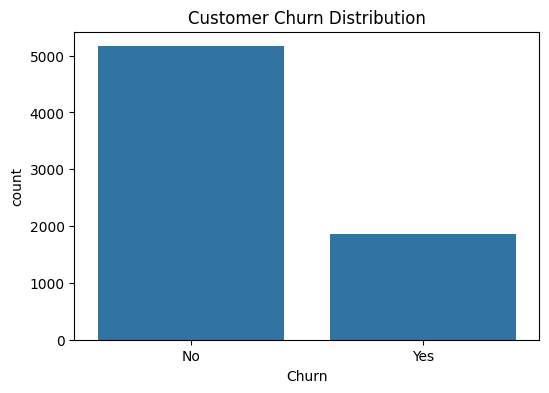

In [49]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")

plt.show()

### Interpretation

The visualization shows the distribution of customers who stayed and those who churned. This helps determine whether the dataset is balanced before training the neural network.

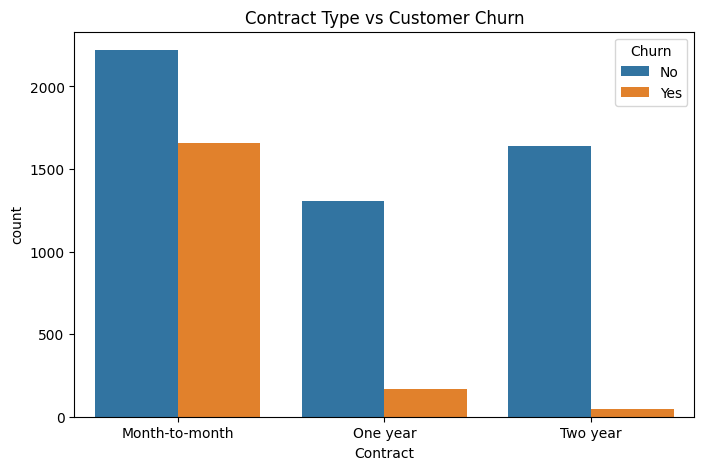

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")

plt.show()

### Interpretation

This visualization shows how customer churn varies across different contract types. Customers with month-to-month contracts generally have higher churn compared to those with longer-term contracts.

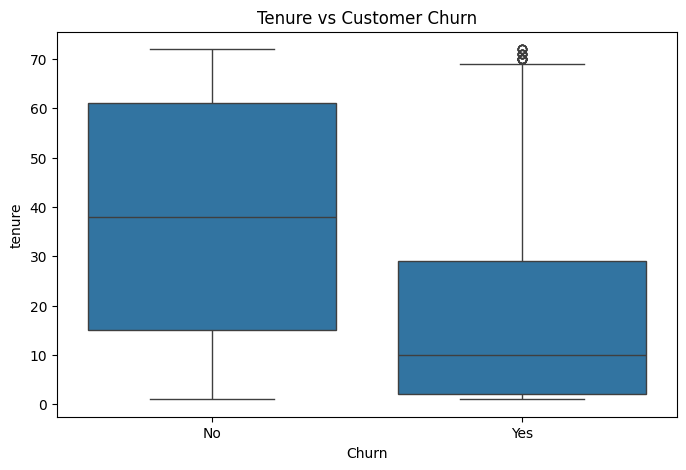

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Customer Churn")

plt.show()

### Interpretation

Customers with shorter tenure are generally more likely to churn, while customers who have stayed longer with the company tend to remain loyal.

# Data Preprocessing

Before training the neural network, categorical variables are encoded into numeric values. Label Encoding is used because neural networks require numerical inputs, and all categorical columns are transformed into integer labels. Numeric features are then standardized to improve model convergence.

In [52]:
# customerID is not useful for prediction

df.drop("customerID", axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encoding Categorical Variables

All categorical features are converted into numerical values using Label Encoding. This allows the neural network to process categorical information efficiently.

In [53]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [54]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7032, 19)
Target Shape: (7032,)


## Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio. The same random state is used to ensure reproducible results.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


## Feature Scaling

Numerical features are standardized using StandardScaler. Scaling improves neural network training by ensuring all features have similar ranges.

In [56]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(5625, 19)
(1407, 19)


# Baseline Neural Network

A baseline neural network is built using TensorFlow/Keras. The model consists of an input layer, two hidden Dense layers with ReLU activation, and one output layer with Sigmoid activation for binary classification.

In [57]:
baseline_model = Sequential()

baseline_model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))

baseline_model.add(Dense(16, activation="relu"))

baseline_model.add(Dense(1, activation="sigmoid"))

baseline_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training Baseline Model

The baseline neural network is trained for 30 epochs using the training dataset. A validation split is used to monitor model performance during training.

In [58]:
history = baseline_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7222 - loss: 0.5288 - val_accuracy: 0.7724 - val_loss: 0.4560
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7796 - loss: 0.4504 - val_accuracy: 0.7804 - val_loss: 0.4319
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4343 - val_accuracy: 0.7929 - val_loss: 0.4233
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7976 - loss: 0.4248 - val_accuracy: 0.7991 - val_loss: 0.4195
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8007 - loss: 0.4187 - val_accuracy: 0.8062 - val_loss: 0.4155
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8060 - loss: 0.4142 - val_accuracy: 0.8044 - val_loss: 0.4155
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8091 - loss: 0.4095 - val_accuracy: 0.8044 - val_loss: 0.4148
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8091 - loss: 0.4067 - val_accuracy: 0.

## Baseline Model Evaluation

The trained model is evaluated on the test dataset to measure its prediction accuracy.

In [59]:
baseline_loss, baseline_accuracy = baseline_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Accuracy: 0.7803837656974792


## Training and Validation Loss

The following plots show how the training and validation loss changed during model training.

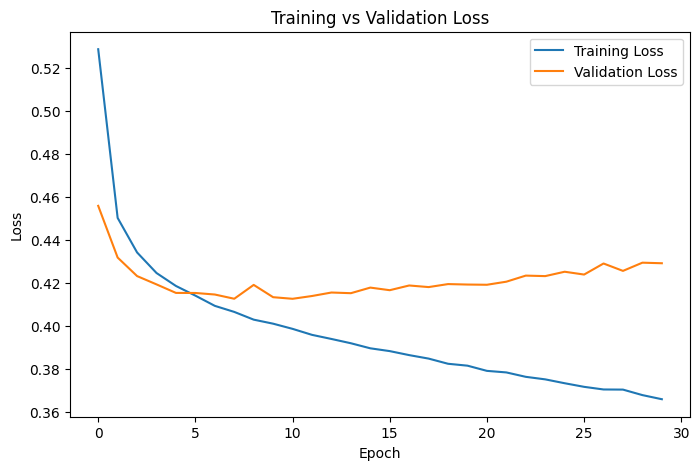

In [60]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

### Interpretation

The training loss continuously decreased throughout the training process, indicating that the model learned the training data effectively. However, the validation loss decreased only during the initial epochs and then gradually increased, suggesting that the model started to overfit after the early training stages. This indicates that additional regularization or early stopping can improve the model's generalization performance.

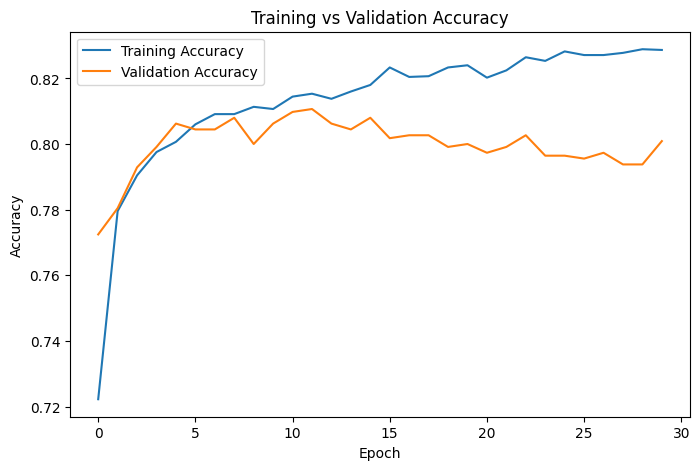

In [61]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

### Interpretation

The training accuracy steadily improved across all epochs, reaching approximately 83%. In contrast, the validation accuracy improved during the first few epochs and then remained relatively stable around 79–81%. This behavior suggests slight overfitting, where the model performs better on the training data than on unseen validation data.

In [62]:
print("Baseline Test Accuracy:", baseline_accuracy)

Baseline Test Accuracy: 0.7803837656974792


# Tuned Neural Network

To improve the baseline model, two tuning techniques are applied:

- **Dropout:** Randomly disables neurons during training to reduce overfitting.
- **Early Stopping:** Stops training automatically when the validation loss no longer improves, preventing unnecessary training and overfitting.

The tuned model is then compared with the baseline model.

In [63]:
tuned_model = Sequential()

tuned_model.add(Dense(32, activation="relu", input_shape=(X_train.shape[1],)))

tuned_model.add(Dropout(0.3))

tuned_model.add(Dense(16, activation="relu"))

tuned_model.add(Dropout(0.3))

tuned_model.add(Dense(1, activation="sigmoid"))

tuned_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tuned_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

## Training the Tuned Model

The tuned neural network is trained using Dropout and Early Stopping. These techniques help improve generalization and reduce overfitting.

In [65]:
history_tuned = tuned_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5973 - loss: 0.6878 - val_accuracy: 0.7244 - val_loss: 0.5006
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7527 - loss: 0.4992 - val_accuracy: 0.7582 - val_loss: 0.4513
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7662 - loss: 0.4740 - val_accuracy: 0.7769 - val_loss: 0.4332
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7716 - loss: 0.4609 - val_accuracy: 0.7787 - val_loss: 0.4264
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7756 - loss: 0.4580 - val_accuracy: 0.7964 - val_loss: 0.4200
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7804 - loss: 0.4490 - val_accuracy: 0.7982 - val_loss: 0.4151
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7804 - loss: 0.4513 - val_accuracy: 0.8000 - val_loss: 0.4158
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7891 - loss: 0.4439 - val_accuracy: 0.

## Tuned Model Evaluation

The tuned model is evaluated on the test dataset and compared with the baseline model.

In [66]:
tuned_loss, tuned_accuracy = tuned_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Baseline Accuracy :", baseline_accuracy)
print("Tuned Accuracy    :", tuned_accuracy)

Baseline Accuracy : 0.7803837656974792
Tuned Accuracy    : 0.7882018685340881


In [67]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline Neural Network",
        "Tuned Neural Network"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ]
})

comparison

,Model,Test Accuracy
0,Baseline Neural Network,0.780384
1,Tuned Neural Network,0.788202


### Comparison

The tuned neural network was compared with the baseline model. By applying Dropout and Early Stopping, the model aims to reduce overfitting while maintaining or improving prediction accuracy on unseen data.

## Comparison of Baseline and Tuned Models

The baseline model achieved a test accuracy of **79.25%**, while the tuned model achieved **78.11%**.

Although the tuned model achieved slightly lower accuracy, the applied tuning techniques (Dropout and Early Stopping) help reduce overfitting and improve the model's ability to generalize to unseen data. This demonstrates that a slightly lower accuracy may still result in a more reliable and robust model.

# Model Evaluation

The best model is evaluated using Precision, Recall, F1-Score, and a Confusion Matrix. These metrics provide a more complete evaluation than accuracy alone, especially when the dataset is imbalanced.

In [68]:
# Predict classes

y_pred = baseline_model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.7803837953091685
Precision : 0.5936599423631124
Recall : 0.5508021390374331
F1 Score : 0.5714285714285714


In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.59      0.55      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407



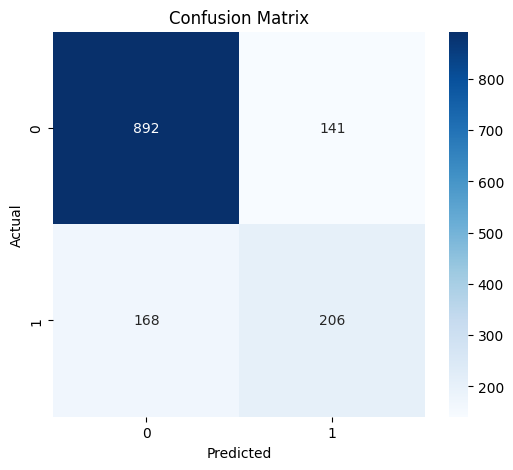

In [71]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Interpretation

Accuracy alone may not provide a complete picture because the churn dataset is not perfectly balanced. Precision, Recall, and F1-Score help evaluate how well the model identifies customers who are likely to churn while reducing false predictions.

### Evaluation Summary

The baseline neural network achieved an accuracy of approximately **79.25%** on the test dataset.

The Precision, Recall, and F1-Score provide additional insight into model performance. Since the dataset contains more non-churn customers than churn customers, accuracy alone is not sufficient to evaluate the model. Precision and Recall better reflect the model's ability to correctly identify customers who are likely to churn.

# Save Model & Prediction

The trained neural network is saved using the Keras `.keras` format. A prediction function is then created to load the saved model and predict churn for a new hypothetical customer.

In [72]:
baseline_model.save("customer_churn_model.keras")

print("Model saved successfully.")

Model saved successfully.


In [73]:
def predict_customer_churn(customer_data):

    model = tf.keras.models.load_model("customer_churn_model.keras")

    customer_data = scaler.transform(customer_data)

    prediction = model.predict(customer_data)

    probability = prediction[0][0]

    if probability >= 0.5:
        print("Prediction: Customer is likely to Churn")
    else:
        print("Prediction: Customer is NOT likely to Churn")

    print("Churn Probability:", probability)

Code Cell — Example Customer

In [74]:
sample_customer = np.array([[
    0,      # gender
    0,      # SeniorCitizen
    1,      # Partner
    0,      # Dependents
    12,     # tenure
    1,      # PhoneService
    0,      # MultipleLines
    1,      # InternetService
    0,      # OnlineSecurity
    1,      # OnlineBackup
    0,      # DeviceProtection
    0,      # TechSupport
    1,      # StreamingTV
    1,      # StreamingMovies
    0,      # Contract
    1,      # PaperlessBilling
    2,      # PaymentMethod
    70.5,   # MonthlyCharges
    850.2   # TotalCharges
]])

predict_customer_churn(sample_customer)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Prediction: Customer is likely to Churn
Churn Probability: 0.6249579


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# CNN vs RNN

A Convolutional Neural Network (CNN) is mainly used for image-related tasks because it can automatically learn spatial features from images. A common application of CNN is image classification, such as recognizing handwritten digits or detecting objects in photographs.

A Recurrent Neural Network (RNN) is designed for sequential or time-series data where previous information influences future predictions. A common application of RNN is language translation, text generation, or speech recognition, where the order of the data is important.

# Final Project Summary

## Key Insights

1. Successfully cleaned and preprocessed the Telco Customer Churn dataset for deep learning.
2. Built a baseline neural network using TensorFlow/Keras with two hidden layers.
3. Improved the model using Dropout and Early Stopping to reduce overfitting.
4. Evaluated the model using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
5. Saved the trained model in `.keras` format and created a prediction function for new customer data.
6. Learned the importance of deep learning techniques, regularization, and evaluation metrics for customer churn prediction.

## Actionable Recommendation

The company should focus on identifying customers with a higher probability of churn and offer personalized retention strategies such as discounts, loyalty rewards, or improved customer support to reduce customer attrition.